In [556]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name
)

In [557]:
x = [
            0,
            0., 0, 0., 0, 0, 0,
            0.0, 0, 0.0, 0, 0, 0,
            0., 0, 0., 0.0, 0, 0,
        ] # NOTE: no interaction -> metal

# # Single fermion/site
# x = [
#             3,
#             0., 0, 0., 0, 1, 0,
#             0.0, 0, 0.0, 0, 1, 0,
#             0., 0, 0., 0.0, 0, 1,
#         ] # NOTE: A & B up C down -> metal


# x = [
#             3,
#             0., 0, 0., 0, 0, 1,
#             0.0, 0, 0.0, 0, 1, 0,
#             0., 0, 0., 0.0, 0, 1,
#         ] # NOTE: A & C down, B up -> TI

# # Double fermion/site
# x = [
#             3,
#             0., 0.5, 0., 0.5, 0, 1,
#             0.5, 0, 0.5, 0, 1, 0,
#             0., 0.5, 0., 0.5, 0, 1,
#         ] # NOTE: A & C down, B up -> TI ?

In [558]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC=0.0, t_1=-1, U=0.0):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    # Chosen occupancies for net spin == 0
    for label_i in subs:
        if label_i == "A":
            n_px_up = x[1]
            n_px_down = x[2]
            n_py_up = x[3]
            n_py_down = x[4]
            n_pz_up = x[5]
            n_pz_down = x[6]
        elif label_i == "B":
            n_px_up = x[7]
            n_px_down = x[8]
            n_py_up = x[9]
            n_py_down = x[10]
            n_pz_up = x[11]
            n_pz_down = x[12]
        else:
            n_px_up = x[13]
            n_px_down = x[14]
            n_py_up = x[15]
            n_py_down = x[16]
            n_pz_up = x[17]
            n_pz_down = x[18]
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["onsite_energy"][label_i]["E_s"] = -5
        parser["interaction"][label_i]["U_p"] = x[0]
        parser["interaction"][label_i]["n_px_up"] = n_px_up
        parser["interaction"][label_i]["n_px_down"] = n_px_down
        parser["interaction"][label_i]["n_py_up"] = n_py_up
        parser["interaction"][label_i]["n_py_down"] = n_py_down
        parser["interaction"][label_i]["n_pz_up"] = n_pz_up
        parser["interaction"][label_i]["n_pz_down"] = n_pz_down
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.01 * np.abs(t_1)
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1/2
            except:
                pass
        # print(parser)   
set_eigenvalues(problem, -0.2, -1)

In [559]:
location = "bulk"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 150, # reciprocal space discretization
    location = location,
    BZ="reduced"
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


In [560]:
g = problem.geometry
tb_bulk = problem.hamiltonian[location]["tight_binding"]

In [561]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [562]:
invariants = problem.hamiltonian["bulk"]["topological_invariants"]

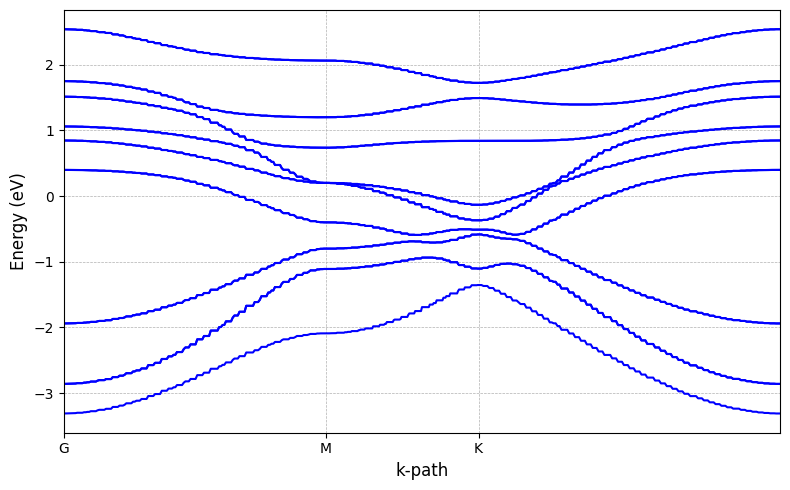

In [563]:
bands = [i for i in range(7, 24)]
tb_bulk.plot_band_structure(g, bands)

In [564]:
dE, E0, E1 = invariants.get_band_gap(22, 21, only_dE=False)
dE

np.float64(-0.027021526399230833)

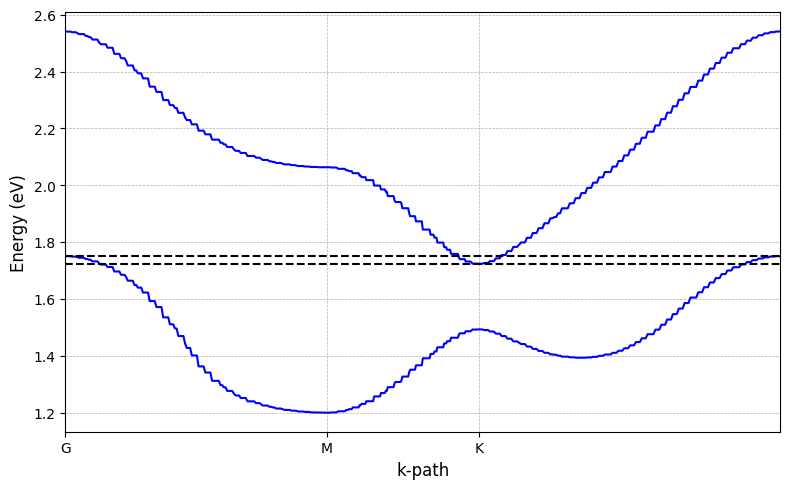

In [565]:
tb_bulk.plot_band_structure(g, [21, 22], energies=[E0, E1])

In [566]:
# Z_2 = invariants.Z2_invariant(bands= [23, 22], print_deltas=True)
# print("")
# print(f"Z2 = {Z_2}")

In [567]:
# C, F = invariants.non_abelian_chern_invariant([22, 23])
# print(C/3)
# invariants.plot_berry_flux(F)